# 04 — Predictive intelligence, statistical evidence and management priorities
**Business questions:** Do machine-learned customer groups add usable information? Can late-delivery risk be ranked early enough to support intervention?

**Contents:** clustering diagnostics and profiles; leakage-safe temporal classification; threshold and error tradeoffs; focused statistics; final recommendations. Model success is evaluated honestly, including limited practical usefulness.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
pd.set_option('display.max_columns', 18)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
def table(name): return pd.read_csv(ROOT / 'output' / (name + '.csv'))
def chart(name): display(Image(filename=str(ROOT / 'images' / name), width=950))
def decision(evidence, interpretation, action, kpi):
    display(Markdown(f'**What the data shows:** {evidence}\n\n**Business interpretation:** {interpretation}\n\n**Recommended action:** {action}\n\n**KPI to monitor:** {kpi}'))

## Run the reproducible model workflow
Clustering: inspect skew → cap at 99th percentile → log1p → standardize → K=2–6 → silhouette/inertia → seed stability/size → original-unit profile.

Classification: order placement/approval features → 60/20/20 purchase-time splits → purge labels unavailable at boundaries → train-only preprocessing → model selection by validation average precision → threshold selection by validation F1 → one final holdout evaluation. No realized delivery, review or future seller-performance feature enters the predictors.

In [2]:
from src.pipeline import data_science,executive_report
metrics=data_science(ROOT)

Clustering customers...


Training and evaluating temporal late-delivery models...


## Customer clustering: does it add information?
Frequency is highly concentrated at one. A high silhouette can result from recovering the rare repeat-purchase group rather than discovering rich commercial personas. Examine original-unit profiles before deciding to use a more complex segmentation.

,feature,skew_before,upper_cap_99pct,capped_customers
0,recency,0.4475,576.0000,882
1,frequency,11.0952,2.0000,228
2,monetary,9.7469,"1,004.9900",929
3,items_per_order,7.6243,3.0000,873


,k,inertia,silhouette,seed_stability_ari,smallest_cluster_share,selected
0,2,"277,965.6936",0.6757,1.0000,0.0300,True
1,3,"191,598.6637",0.5422,1.0000,0.0300,False
2,4,"135,820.1923",0.4114,1.0000,0.0300,False
3,5,"93,887.6935",0.4051,0.9997,0.0300,False
4,6,"81,585.9194",0.3554,0.9867,0.0300,False


,cluster,customers,recency,frequency,monetary,aov,items_per_order,business_name
0,0,2801,220.8094,2.1139,260.0531,122.9586,1.2140,"More recent, above-average value, repeat-orien..."
1,1,90557,239.0254,1.0000,137.9583,137.9583,1.1372,"Less recent, below-average value, single-purch..."


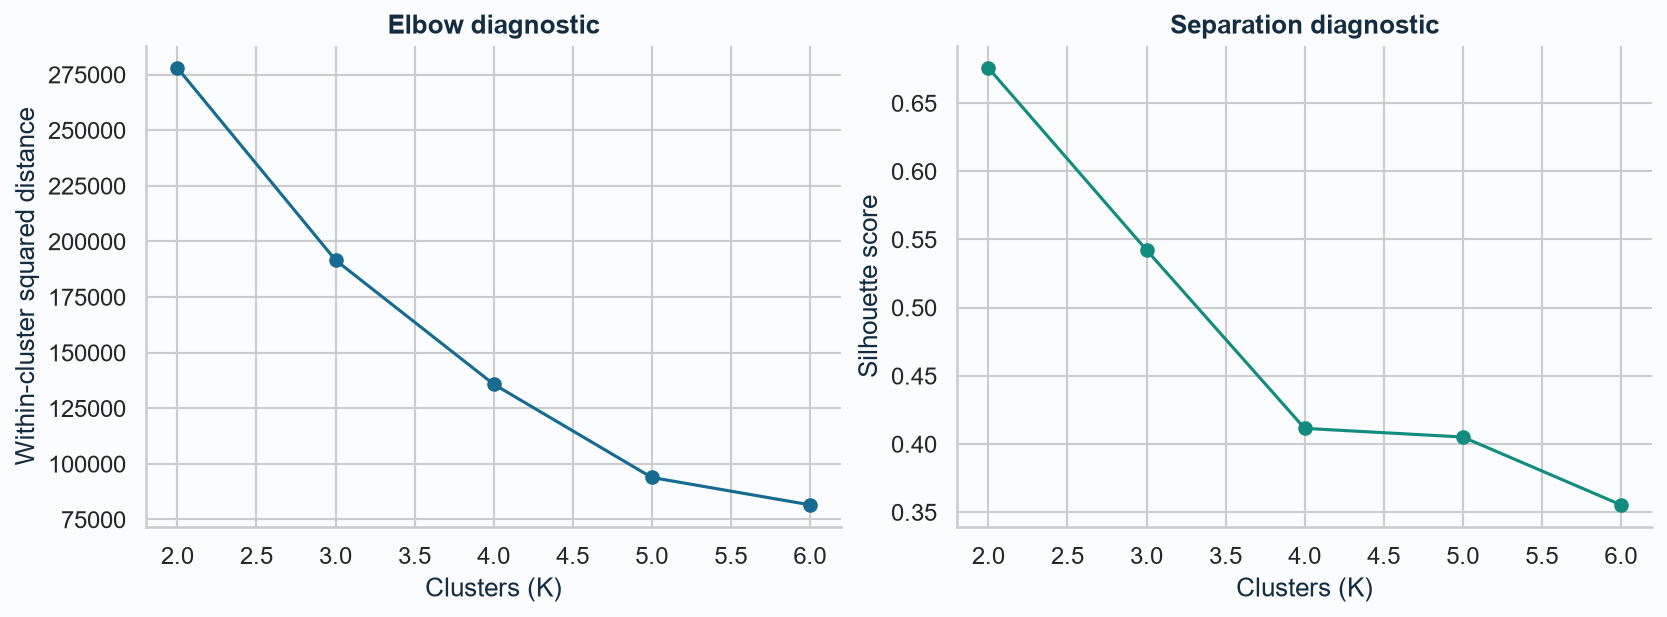

**What the data shows:** The chosen solution contains 2 groups; the largest contains 97.0% of customers.

**Business interpretation:** For this run the two clusters largely reproduce one-time versus repeat customers; strong separation adds little beyond the simpler frequency rule.

**Recommended action:** Prefer simple segment rules unless a controlled marketing test shows additional value from clustering.

**KPI to monitor:** Incremental experiment response, segment stability and minimum cluster size.

In [3]:
display(table('cluster_treatment'))
display(table('cluster_diagnostics'))
display(table('cluster_profiles'))
chart('cluster_diagnostics.png')
profiles=table('cluster_profiles')
decision(f"The chosen solution contains {len(profiles)} groups; the largest contains {profiles.customers.max()/profiles.customers.sum():.1%} of customers.",
         'For this run the two clusters largely reproduce one-time versus repeat customers; strong separation adds little beyond the simpler frequency rule.',
         'Prefer simple segment rules unless a controlled marketing test shows additional value from clustering.',
         'Incremental experiment response, segment stability and minimum cluster size.')

## Late-delivery model comparison
Logistic regression and random forest use class balancing; gradient boosting uses its standard objective. State and primary-item category encode coarse origin/destination/product context. No geolocation proxy or historical seller outcome is fabricated. The temporal holdout includes only orders with valid eventual delivered labels; this selection limits generalization to unresolved/canceled orders.

In [4]:
display(table('model_comparison'))
display(pd.DataFrame([metrics]))
thresholds=table('model_thresholds')
display(thresholds[thresholds.model.eq(metrics['selected_model'])].sort_values('f1',ascending=False).head(10))

,model,validation_ap,validation_roc_auc
0,Random forest,0.1629,0.6518
1,Logistic regression,0.1558,0.6489
2,Gradient boosting,0.1165,0.5977


,selected_model,threshold,train_orders,validation_orders,test_orders,validation_start,test_start,test_prevalence,test_average_precision,test_roc_auc,test_precision,test_recall,test_f1,true_negatives,false_positives,false_negatives,true_positives,excluded_unmatured_labels
0,Random forest,0.4800,53870,17336,19333,2018-03-02 00:00:00,2018-05-25 00:00:00,0.0348,0.0614,0.6918,0.0622,0.3640,0.1063,14967,3693,428,245,5743


,model,threshold,precision,recall,f1,alert_share
72,Random forest,0.4800,0.1820,0.4043,0.2511,0.1889
71,Random forest,0.4600,0.1657,0.4885,0.2475,0.2506
73,Random forest,0.5000,0.1966,0.3107,0.2408,0.1344
70,Random forest,0.4400,0.1510,0.5706,0.2388,0.3213
74,Random forest,0.5200,0.2171,0.2286,0.2227,0.0895
69,Random forest,0.4200,0.1352,0.6214,0.2221,0.3908
68,Random forest,0.4000,0.1206,0.6757,0.2046,0.4766
67,Random forest,0.3800,0.1092,0.7381,0.1903,0.5746
66,Random forest,0.3600,0.0996,0.7883,0.1769,0.6727
75,Random forest,0.5400,0.2335,0.1316,0.1683,0.0479


## Holdout errors and deployment limits
Average precision should be compared to holdout late prevalence. The validation-selected threshold is fixed before holdout evaluation. F1 does not represent an economic optimum; costs and team capacity are unknown. The model remains trained only on the training interval for this honest evaluation. Impurity importance is not used as causal evidence.

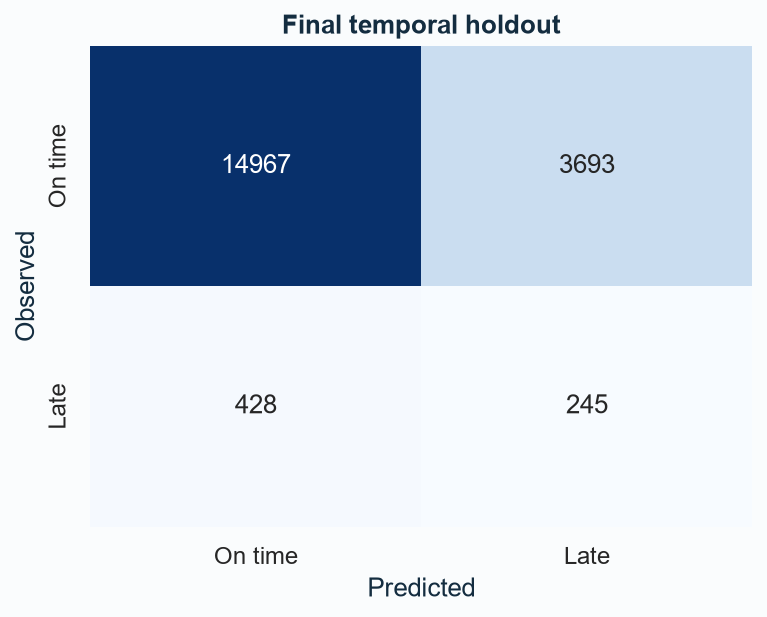

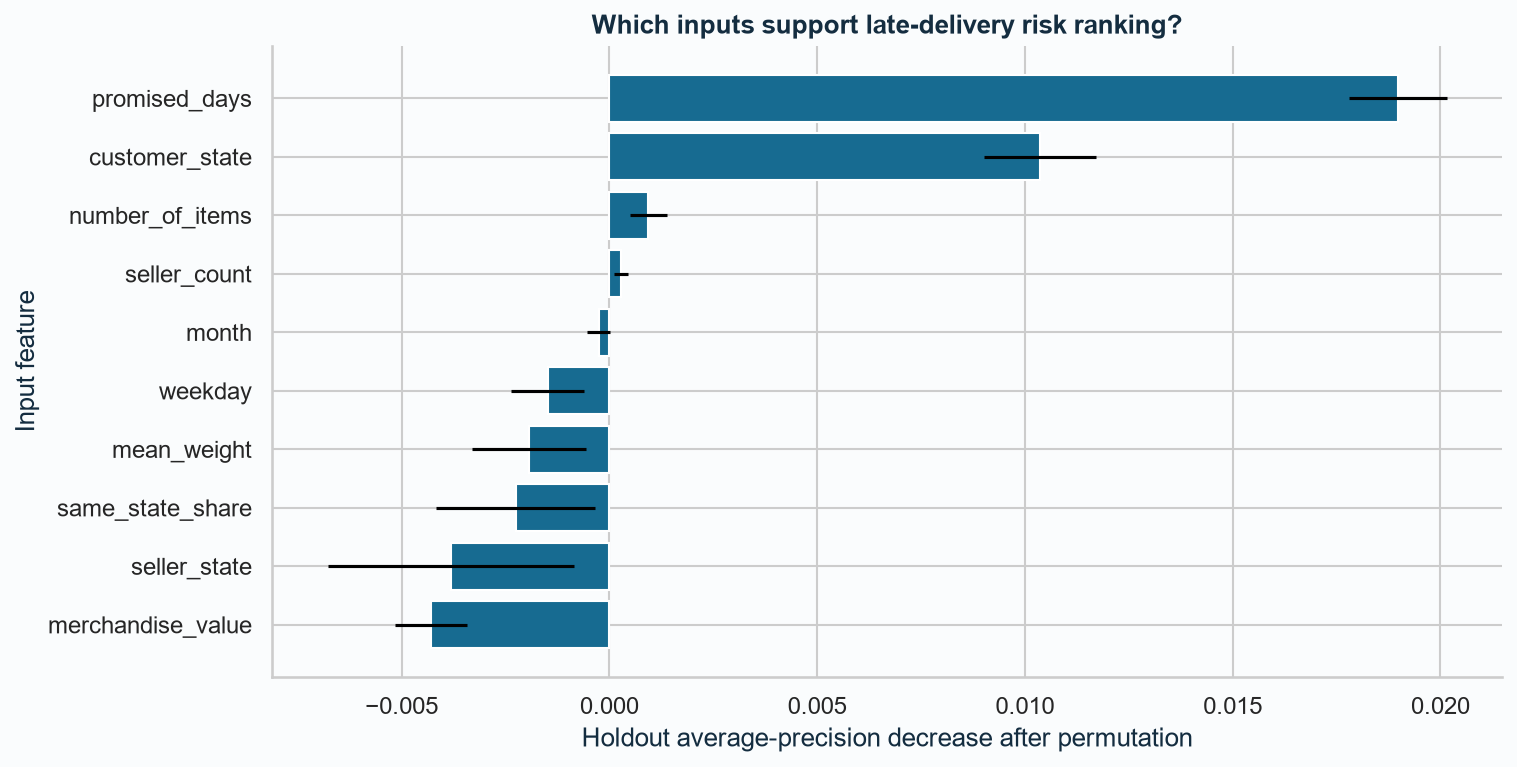

**What the data shows:** Holdout AP 0.061 versus prevalence 0.035; 3,938 alerts include 3,693 false positives.

**Business interpretation:** Precision is only 6.2%; a ranking signal is not proof of an operationally useful alert system.

**Recommended action:** Use shadow evaluation only; establish capacity and costs, check calibration/drift and test benefit before intervention.

**KPI to monitor:** Precision/recall at team capacity, false-alert cost, missed-delay cost and randomized intervention lift.

In [5]:
chart('risk_confusion_matrix.png')
chart('risk_feature_importance.png')
alerts=metrics['true_positives']+metrics['false_positives']
decision(f"Holdout AP {metrics['test_average_precision']:.3f} versus prevalence {metrics['test_prevalence']:.3f}; {alerts:,} alerts include {metrics['false_positives']:,} false positives.",
         f"Precision is only {metrics['test_precision']:.1%}; a ranking signal is not proof of an operationally useful alert system.",
         'Use shadow evaluation only; establish capacity and costs, check calibration/drift and test benefit before intervention.',
         'Precision/recall at team capacity, false-alert cost, missed-delay cost and randomized intervention lift.')

## Focused statistical comparisons
**H0:** compared order-level distributions are equal. **H1:** they differ. Reviews are ordinal with ties and GMV is skewed, so Mann–Whitney U is used, with medians and rank-biserial effect sizes. Independence is imperfect because orders share customers/sellers; p-values are exploratory. Two tests are Bonferroni-adjusted. Do not interpret a p-value as economic importance or causality.

In [6]:
display(table('statistical_tests'))
decision('The test table reports sample size, medians, U, adjusted p-value and effect size.',
         'Large samples can detect small differences; shared sellers/customers complicate independence.',
         'Use effect size and commercial scale to prioritize experiments; validate causality separately.',
         'Effect magnitude, eligible sample sizes and experiment outcomes.')

,comparison,n_a,n_b,median_a,median_b,u_statistic,p_value,rank_biserial_a_over_b,assumption_caveat,p_bonferroni
0,Review scores: late versus on-time,6379,89258,1.0000,5.0000,"103,040,862.5000",0.0000,-0.6381,Order observations may cluster within customer...,0.0000
1,Order GMV: returning versus first,3120,93358,81.0500,86.9000,"141,538,938.0000",0.0074,-0.0281,Order observations may cluster within customer...,0.0148


**What the data shows:** The test table reports sample size, medians, U, adjusted p-value and effect size.

**Business interpretation:** Large samples can detect small differences; shared sellers/customers complicate independence.

**Recommended action:** Use effect size and commercial scale to prioritize experiments; validate causality separately.

**KPI to monitor:** Effect magnitude, eligible sample sizes and experiment outcomes.

## Evidence-based management summary
The report below is regenerated only after the analytics, SQL checks and models execute. Recommendations are hypotheses tied to measurable outcomes.

In [7]:
display(Markdown(executive_report(ROOT)))

# Executive summary

## E-Commerce Decision Intelligence
Growth, Customer Value, Product Performance & Operational Risk

All findings below were generated from the public Olist source files after validation. Values are historical BRL, not current market forecasts or Olist accounting revenue. See `metric_dictionary.md` for populations and `output/` for evidence.

### Six findings

1. Delivered merchandise value was **BRL 13,221,498.11**, across **96,478 orders** and **93,358 unique customers**; AOV was **BRL 137.04**.
2. **3.00%** of customers placed multiple observed eligible orders. Subsequent orders contributed **2.90%** of GMV. Among customers with 90 days of observation, **2.28%** bought again within 90 days. These are observation-window measures, not churn.
3. The highest-spending **45.00%** of customers contributed 80% of GMV. An automatic 80/20 claim is therefore inappropriate; use the measured concentration curves.
4. **6.78%** of delivery-eligible orders arrived after the promised calendar day. Low-review rates were **62.42%** for late orders and **9.26%** for on-time orders. This association does not identify a causal effect.
5. **health beauty** has **BRL 1,233,132** GMV, **7.52%** late deliveries and **8,629** delivery-eligible orders. Its classification is **Improvement priority** under the documented volume, confidence and contribution rules.
6. The selected **Random forest** achieved temporal holdout average precision **0.061** against a prevalence baseline of **0.035**, with recall **36.40%** and precision **6.22%** at threshold **0.48**. Low precision limits practical use: most alerts are false positives. Customer clustering selected **K=2**, with silhouette **0.676** and seed-stability ARI **1.000**. Inspect the profiles: strong separation can simply recover the rare repeat-buyer group, adding little beyond a frequency rule. Intervention value has not been tested.

### Six priorities to test

| Evidence | Proposed action | KPI and evaluation |
|---|---|---|
| Sparse repeat purchasing and unequal observation windows | Randomize an opt-in second-purchase journey among newly acquired customers; use equal 90-day follow-up | Incremental 90-day second-purchase rate and GMV per eligible customer; record incentive costs separately |
| High-volume seller and category delay exposure | Review the highest-priority seller/category pairs in the scorecards; investigate promise accuracy and dispatch processes | Late rate with interval, excess late-order count, low-review rate; compare against a suitable control |
| Large review gap by delivery status | Test proactive delay communication for eligible at-risk orders | Low-review rate, contact rate, satisfaction; verify that operational performance improves as well |
| Model ranking above the reported baseline, if confirmed in a deployment-like test | Shadow-score future orders before any automated intervention; select alert volume against team capacity | Precision/recall at capacity, calibration and drift; establish false-alert and missed-delay costs |
| Measured concentration across customers, categories and sellers | Monitor contribution and performance together; investigate overdependence where exposure is material | Top-N contribution and cumulative GMV share, paired with experience KPIs |
| Accounting and join risks in the original analysis | Use the reconciled order/item model as the shared reporting source | Reconciliation failures, missing payment coverage and SQL/Python agreement |

### Interpretation boundaries

The dataset is historical and observational. No channel spend, acquisition cost, profit margin, returns, market size or experimental interventions are observed. The last eligible month is conservatively censored in retention reporting. Delivered-only commercial results exclude unresolved and canceled orders. Seller/category experience uses order-level outcomes, including shared multi-seller orders; this cannot establish seller-level responsibility. Cluster separation, model metrics and correlations do not prove commercial benefit.

Native Power BI execution is not part of the Python run. Dashboard previews are rendered from real calculated data; DAX, Power Query, relationships and a four-page specification are supplied for Power BI Desktop implementation.


## Reproducibility and limitations
Data provenance and hashes are in `data/source_manifest.json`. Runtime requirements and exact validation evidence are delivered with the project. The public history lacks CAC, marketing channels, margins, returns, reliable churn labels and market-size data. Observational associations do not establish causality. Customer exposure is uneven, repeat behavior is sparse and model labels condition on delivered orders.

The Power BI package includes six core CSV tables, optional audit tables, relationship instructions, DAX, Power Query and four real-data page previews. Native Desktop/DAX validation is still required before calling it a working Power BI report.